# Momepy roads 

This notebook uses momepy to calculate geometrical features of the streets, such as width and openess.

## Import libraries

In [35]:
import momepy as mm
import geopandas as gpd
import osmnx as ox
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

## Import streets segments

In [36]:
edges = gpd.read_file("data/bcn_osmnx_edges.gpkg")
print(edges.crs)  #CRS = Coordinate Reference System
print(edges.shape)
print(edges.columns.tolist())
print("Number of street segments:", len(edges))

EPSG:25831
(16541, 21)
['u', 'v', 'key', 'osmid', 'highway', 'lanes', 'maxspeed', 'name', 'oneway', 'reversed', 'length', 'access', 'junction', 'ref', 'width', 'est_width', 'tunnel', 'bridge', 'service', 'segment_id', 'geometry']
Number of street segments: 16541


## Import and project buildings

In [37]:
# Load layers
buildings = gpd.read_file("../../layers/bcn_catastral_building_part.gpkg")

# Ensure CRS is the same
buildings = buildings.to_crs(edges.crs)
buildings['numberOfFloorsAboveGround'].describe()

count    319083.000000
mean          3.612953
std           3.202672
min           0.000000
25%           1.000000
50%           3.000000
75%           6.000000
max         100.000000
Name: numberOfFloorsAboveGround, dtype: float64

## Get estimated number of floors

All buildings have assigned floors. Median is: 3.0


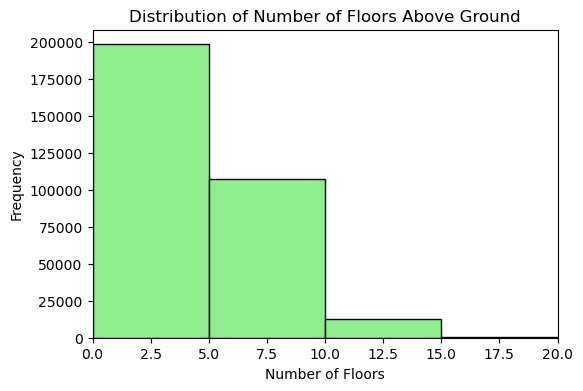

In [38]:

# Process the number of floors
def clean_floors_col(series):
    # Remove non-numeric characters and convert to float
    return pd.to_numeric(series.astype(str).str.replace(r'[^\d.]', '', regex=True), errors='coerce')

# Initialize a series for estimated floors
floors = clean_floors_col(buildings['numberOfFloorsAboveGround'])

buildings['estimated_floors'] = floors

print(f"All buildings have assigned floors. Median is: {median_floors:.1f}")

fig, ax = plt.subplots(figsize=(6, 4))
buildings['estimated_floors'].plot(kind='hist', bins=20, ax=ax, color='lightgreen', edgecolor='black')
buildings['height_derived']=buildings['estimated_floors'] * 3  # Assuming an average floor height of 3 meters
ax.set_title('Distribution of Number of Floors Above Ground')
ax.set_xlabel('Number of Floors')
ax.set_xlim(0, 20)  # Focus on the majority
plt.show()

## Create Momepy street profile

In [39]:
profile = mm.street_profile(edges, buildings, height = buildings['height_derived'].clip(0, 30))  # Clip heights to a reasonable range
profile.head()

,width,openness,width_deviation,height,height_deviation,hw_ratio
0,0.000000,0.000000,0.000000,0.0,0.000000,NaN
1,0.000000,0.000000,0.000000,0.0,0.000000,NaN
2,28.095584,0.750000,0.000669,12.0,0.000000,0.427113
3,15.315967,0.666667,0.513226,12.0,0.000000,0.783496
4,16.687042,0.666667,1.260480,6.0,8.485281,0.359560


In [40]:
edges[profile.columns] = profile
edges[profile.columns].head()

,width,openness,width_deviation,height,height_deviation,hw_ratio
0,0.000000,0.000000,0.000000,0.0,0.000000,NaN
1,0.000000,0.000000,0.000000,0.0,0.000000,NaN
2,28.095584,0.750000,0.000669,12.0,0.000000,0.427113
3,15.315967,0.666667,0.513226,12.0,0.000000,0.783496
4,16.687042,0.666667,1.260480,6.0,8.485281,0.359560


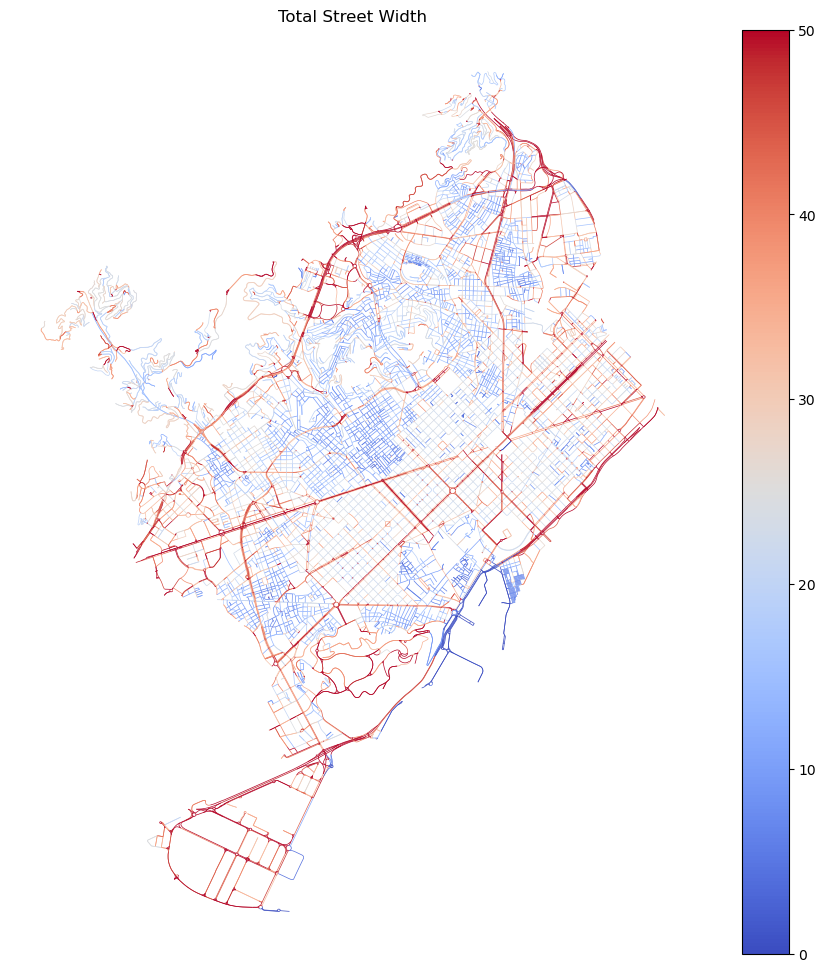

In [41]:
ax = edges.plot(cmap="coolwarm", column='width', linewidth=0.5, legend=True, figsize=(12, 12))
ax.set_title('Total Street Width')
ax.set_axis_off()

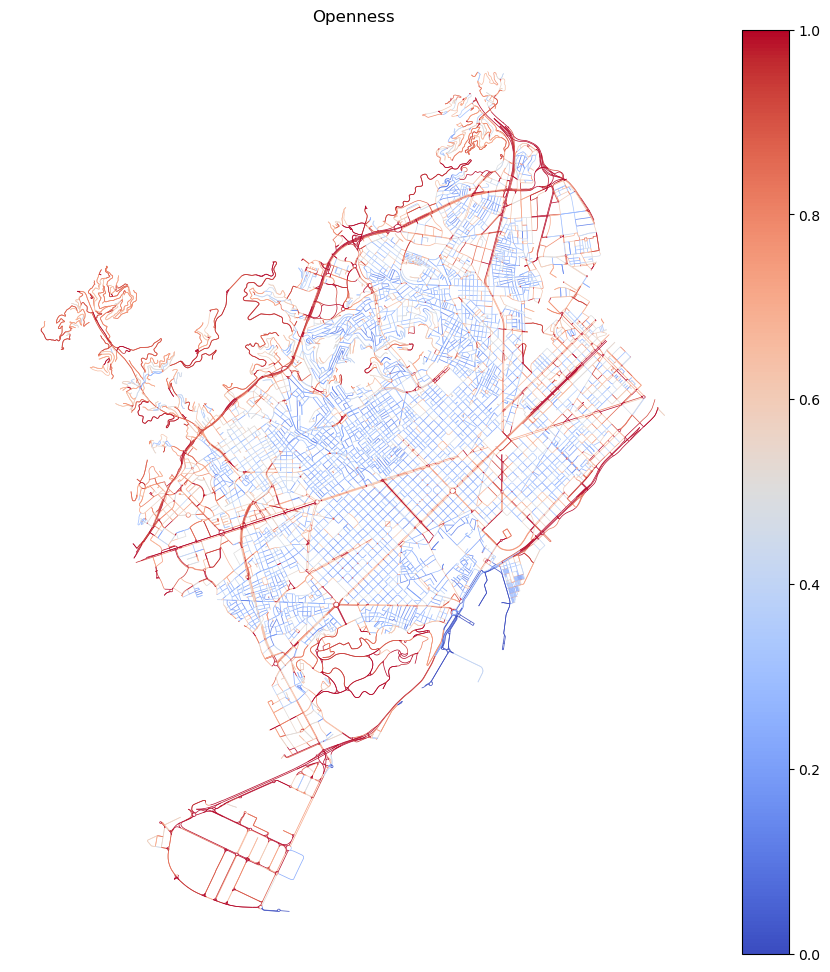

In [42]:
ax = edges.plot(cmap="coolwarm", column='openness', linewidth=0.5, legend=True, figsize=(12, 12))
ax.set_title('Openness')
ax.set_axis_off()

In [ ]:
ax = edges.plot(cmap="coolwarm", column='height', linewidth=0.5, legend=True, figsize=(12, 12))
ax.set_title('Canyon Height')
ax.set_axis_off()

NameError: name 'edges' is not defined

# Centrality

## Betweenness Centrality

In [44]:
primal = mm.gdf_to_nx(edges, approach="primal")

Careful, takes long

In [45]:
betweenness = mm.betweenness_centrality(
    primal, name="betweenness_metric_e", mode="edges", weight="mm_len"
)

In [46]:
primal_gdf_betw = mm.nx_to_gdf(betweenness, points=False)
primal_gdf_betw.head()

,u,v,__key,osmid,highway,lanes,maxspeed,name,oneway,reversed,...,service,segment_id,geometry,openness,width_deviation,height,height_deviation,hw_ratio,mm_len,betweenness_metric_e
0,21638845,885308258,0,554707785,residential,2,30,Passeig de Joan de Borbó,True,False,...,NaN,21638845_885308258_0,"LINESTRING (432071.186 4580160.408, 432067.928...",0.0,0.0,0.0,0.0,NaN,28.292092,0.000896
1,21638845,13175411896,0,"[4079500, 1433594636, 1522870832, 543357596, 9...",residential,"['4', '3']",30,Passeig de Joan de Borbó,False,True,...,NaN,21638845_13175411896_0,"LINESTRING (432071.186 4580160.408, 432066.515...",0.0,0.0,0.0,0.0,NaN,615.655095,0.002015
2,13175411896,21638845,0,"[1433594636, 4079500, 1522870832, 543357596, 9...",residential,"['4', '3']",30,Passeig de Joan de Borbó,False,False,...,NaN,13175411896_21638845_0,"LINESTRING (432176.044 4580757.599, 432174.921...",0.0,0.0,0.0,0.0,NaN,615.655095,0.002015
3,885308314,21638845,0,554707788,residential,2,30,Passeig de Joan de Borbó,True,False,...,NaN,885308314_21638845_0,"LINESTRING (432087.076 4580133.49, 432071.186 ...",0.0,0.0,0.0,0.0,NaN,31.257819,0.000896
4,885308258,885308166,0,"[74975048, 214435425]",residential,"['1', '2']",30,Passeig de Joan de Borbó,True,False,...,NaN,885308258_885308166_0,"LINESTRING (432067.928 4580132.304, 432066.177...",0.0,0.0,0.0,0.0,NaN,119.292946,0.000672


Text(0.5, 1.0, 'Betweenness Centrality (Edge Based)')

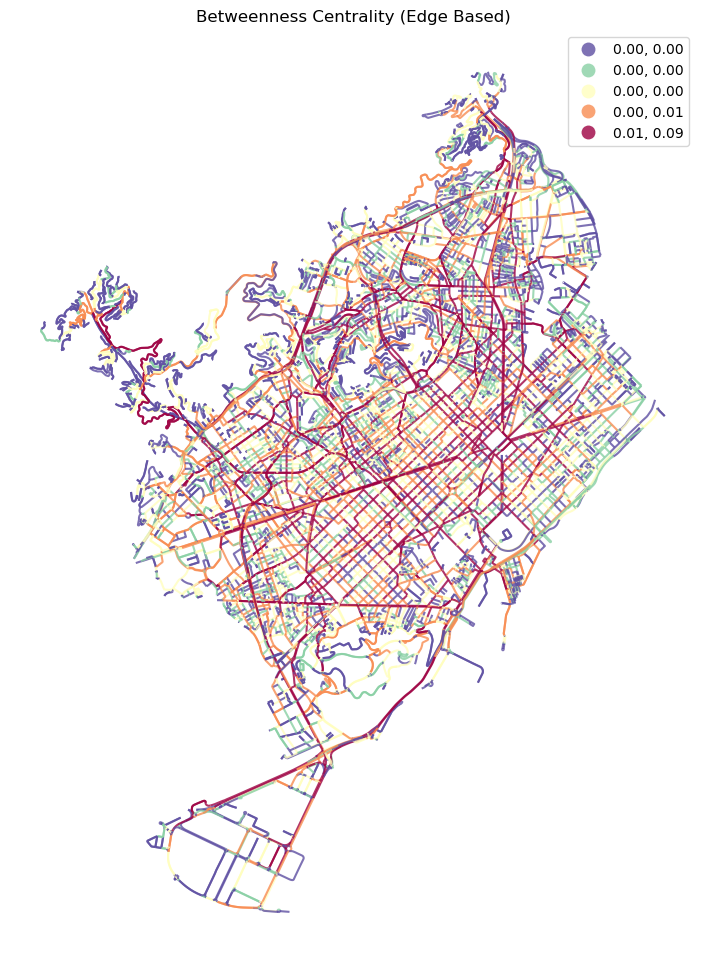

In [47]:
ax = primal_gdf_betw.plot(
    column="betweenness_metric_e",
    cmap="Spectral_r",
    scheme="quantiles",
    alpha=0.8,
    legend=True,
    figsize=(12, 12)
)
ax.set_axis_off()
ax.set_title("Betweenness Centrality (Edge Based)")

## Global Closenness Centrality

Careful, takes long

In [48]:
closeness = mm.closeness_centrality(
    primal, name="closeness_global", weight="mm_len"
)

In [49]:
nodes = mm.nx_to_gdf(closeness, lines=False)
nodes.head()

,x,y,closeness_global,nodeID,geometry
0,432071.185960,4.580160e+06,0.000147,0,POINT (432071.186 4580160.408)
1,432067.928377,4.580132e+06,0.000146,1,POINT (432067.928 4580132.304)
2,432176.043537,4.580758e+06,0.000162,2,POINT (432176.044 4580757.599)
3,432319.661133,4.580900e+06,0.000161,3,POINT (432319.661 4580899.827)
4,432304.736209,4.580896e+06,0.000161,4,POINT (432304.736 4580895.659)


Text(0.5, 1.0, 'Closenness Global (Node Based)')

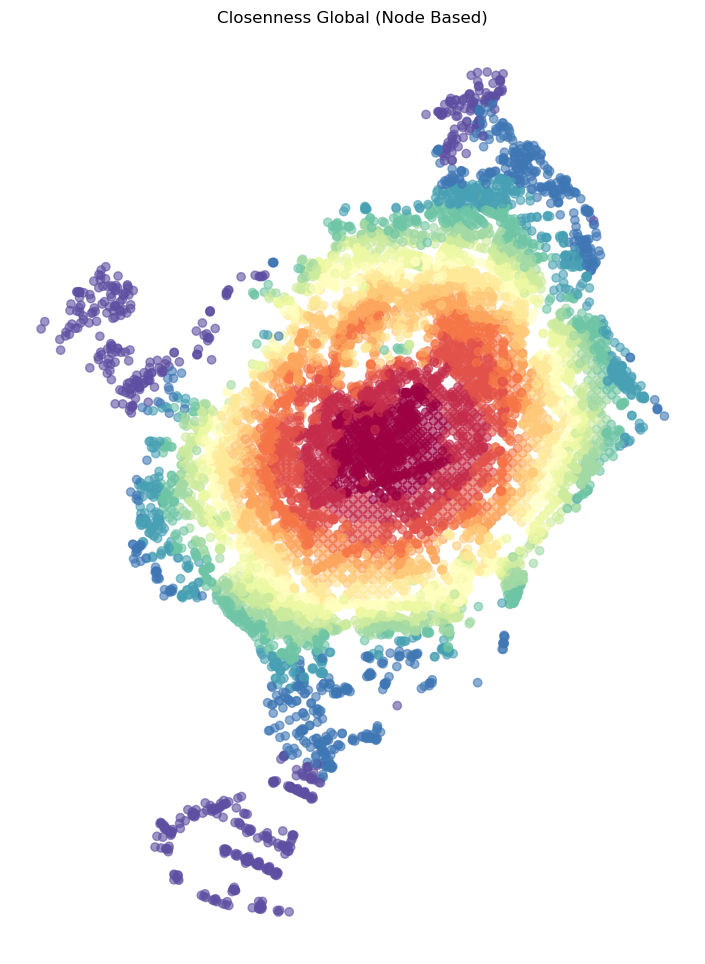

In [50]:
ax = nodes.plot(
    column="closeness_global",
    cmap="Spectral_r",
    scheme="quantiles",
    k=15,
    alpha=0.6,
    figsize=(12, 12),
)
ax.set_axis_off()
ax.set_title("Closenness Global (Node Based)")

In [51]:
mm.mean_nodes(closeness, "closeness_global")

In [52]:
primal_gdf_clos = mm.nx_to_gdf(closeness, points=False)
primal_gdf_clos.head()

,u,v,__key,osmid,highway,lanes,maxspeed,name,oneway,reversed,...,service,segment_id,geometry,openness,width_deviation,height,height_deviation,hw_ratio,mm_len,closeness_global
0,21638845,885308258,0,554707785,residential,2,30,Passeig de Joan de Borbó,True,False,...,NaN,21638845_885308258_0,"LINESTRING (432071.186 4580160.408, 432067.928...",0.0,0.0,0.0,0.0,NaN,28.292092,0.000147
1,21638845,13175411896,0,"[4079500, 1433594636, 1522870832, 543357596, 9...",residential,"['4', '3']",30,Passeig de Joan de Borbó,False,True,...,NaN,21638845_13175411896_0,"LINESTRING (432071.186 4580160.408, 432066.515...",0.0,0.0,0.0,0.0,NaN,615.655095,0.000154
2,13175411896,21638845,0,"[1433594636, 4079500, 1522870832, 543357596, 9...",residential,"['4', '3']",30,Passeig de Joan de Borbó,False,False,...,NaN,13175411896_21638845_0,"LINESTRING (432176.044 4580757.599, 432174.921...",0.0,0.0,0.0,0.0,NaN,615.655095,0.000154
3,885308314,21638845,0,554707788,residential,2,30,Passeig de Joan de Borbó,True,False,...,NaN,885308314_21638845_0,"LINESTRING (432087.076 4580133.49, 432071.186 ...",0.0,0.0,0.0,0.0,NaN,31.257819,0.000147
4,885308258,885308166,0,"[74975048, 214435425]",residential,"['1', '2']",30,Passeig de Joan de Borbó,True,False,...,NaN,885308258_885308166_0,"LINESTRING (432067.928 4580132.304, 432066.177...",0.0,0.0,0.0,0.0,NaN,119.292946,0.000145


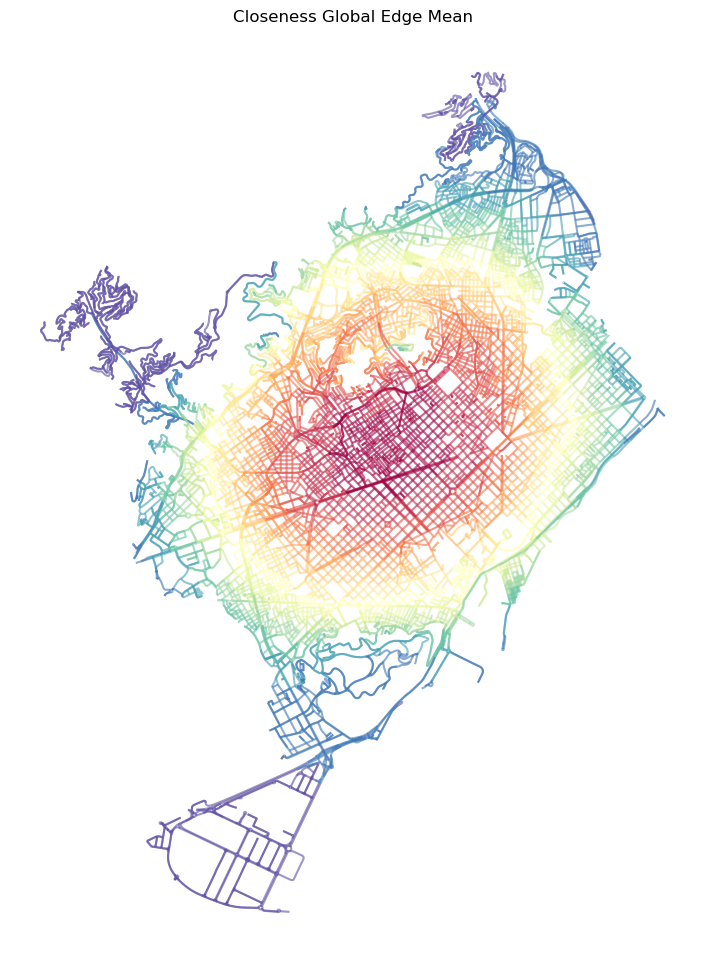

In [53]:

ax = primal_gdf_clos.plot(
    column="closeness_global",
    cmap="Spectral_r",
    scheme="quantiles",
    k=15,
    alpha=0.6,
    figsize=(12, 12),
)
ax.set_axis_off()
_ = ax.set_title("Closeness Global Edge Mean")

In [54]:
# Merge on 'segment_id' (or the appropriate key)
primal_gdf = primal_gdf_betw.merge(
    primal_gdf_clos[['segment_id', 'closeness_global']],
    on='segment_id',
    how='left'
)
primal_gdf.head()

,u,v,__key,osmid,highway,lanes,maxspeed,name,oneway,reversed,...,segment_id,geometry,openness,width_deviation,height,height_deviation,hw_ratio,mm_len,betweenness_metric_e,closeness_global
0,21638845,885308258,0,554707785,residential,2,30,Passeig de Joan de Borbó,True,False,...,21638845_885308258_0,"LINESTRING (432071.186 4580160.408, 432067.928...",0.0,0.0,0.0,0.0,NaN,28.292092,0.000896,0.000147
1,21638845,13175411896,0,"[4079500, 1433594636, 1522870832, 543357596, 9...",residential,"['4', '3']",30,Passeig de Joan de Borbó,False,True,...,21638845_13175411896_0,"LINESTRING (432071.186 4580160.408, 432066.515...",0.0,0.0,0.0,0.0,NaN,615.655095,0.002015,0.000154
2,13175411896,21638845,0,"[1433594636, 4079500, 1522870832, 543357596, 9...",residential,"['4', '3']",30,Passeig de Joan de Borbó,False,False,...,13175411896_21638845_0,"LINESTRING (432176.044 4580757.599, 432174.921...",0.0,0.0,0.0,0.0,NaN,615.655095,0.002015,0.000154
3,885308314,21638845,0,554707788,residential,2,30,Passeig de Joan de Borbó,True,False,...,885308314_21638845_0,"LINESTRING (432087.076 4580133.49, 432071.186 ...",0.0,0.0,0.0,0.0,NaN,31.257819,0.000896,0.000147
4,885308258,885308166,0,"[74975048, 214435425]",residential,"['1', '2']",30,Passeig de Joan de Borbó,True,False,...,885308258_885308166_0,"LINESTRING (432067.928 4580132.304, 432066.177...",0.0,0.0,0.0,0.0,NaN,119.292946,0.000672,0.000145


In [57]:
dataset = pd.DataFrame({
    "road_id": primal_gdf['segment_id'],
    "width": primal_gdf['width'],
    "height": primal_gdf['height'],
    "betw_centrality": primal_gdf['betweenness_metric_e'],
    "clos_centrality": primal_gdf['closeness_global'],
}).fillna(0) #fillna(0) to replace any NaN values with 0

dataset.head()

,road_id,width,height,betw_centrality,clos_centrality
0,21638845_885308258_0,0.0,0.0,0.000896,0.000147
1,21638845_13175411896_0,0.0,0.0,0.002015,0.000154
2,13175411896_21638845_0,0.0,0.0,0.002015,0.000154
3,885308314_21638845_0,0.0,0.0,0.000896,0.000147
4,885308258_885308166_0,0.0,0.0,0.000672,0.000145


## Export dataset to CSV

In [58]:
import os
output_dir = "data"
os.makedirs(output_dir, exist_ok=True)
dataset.to_csv(os.path.join(output_dir, "momepy_roads_features.csv"), index=False)
print("Exported momepy_roads_features.csv")

Exported momepy_roads_features.csv


TODO: using building height we could also calculate street canyon height and h/w ratio, which are relevant for noise propagation.